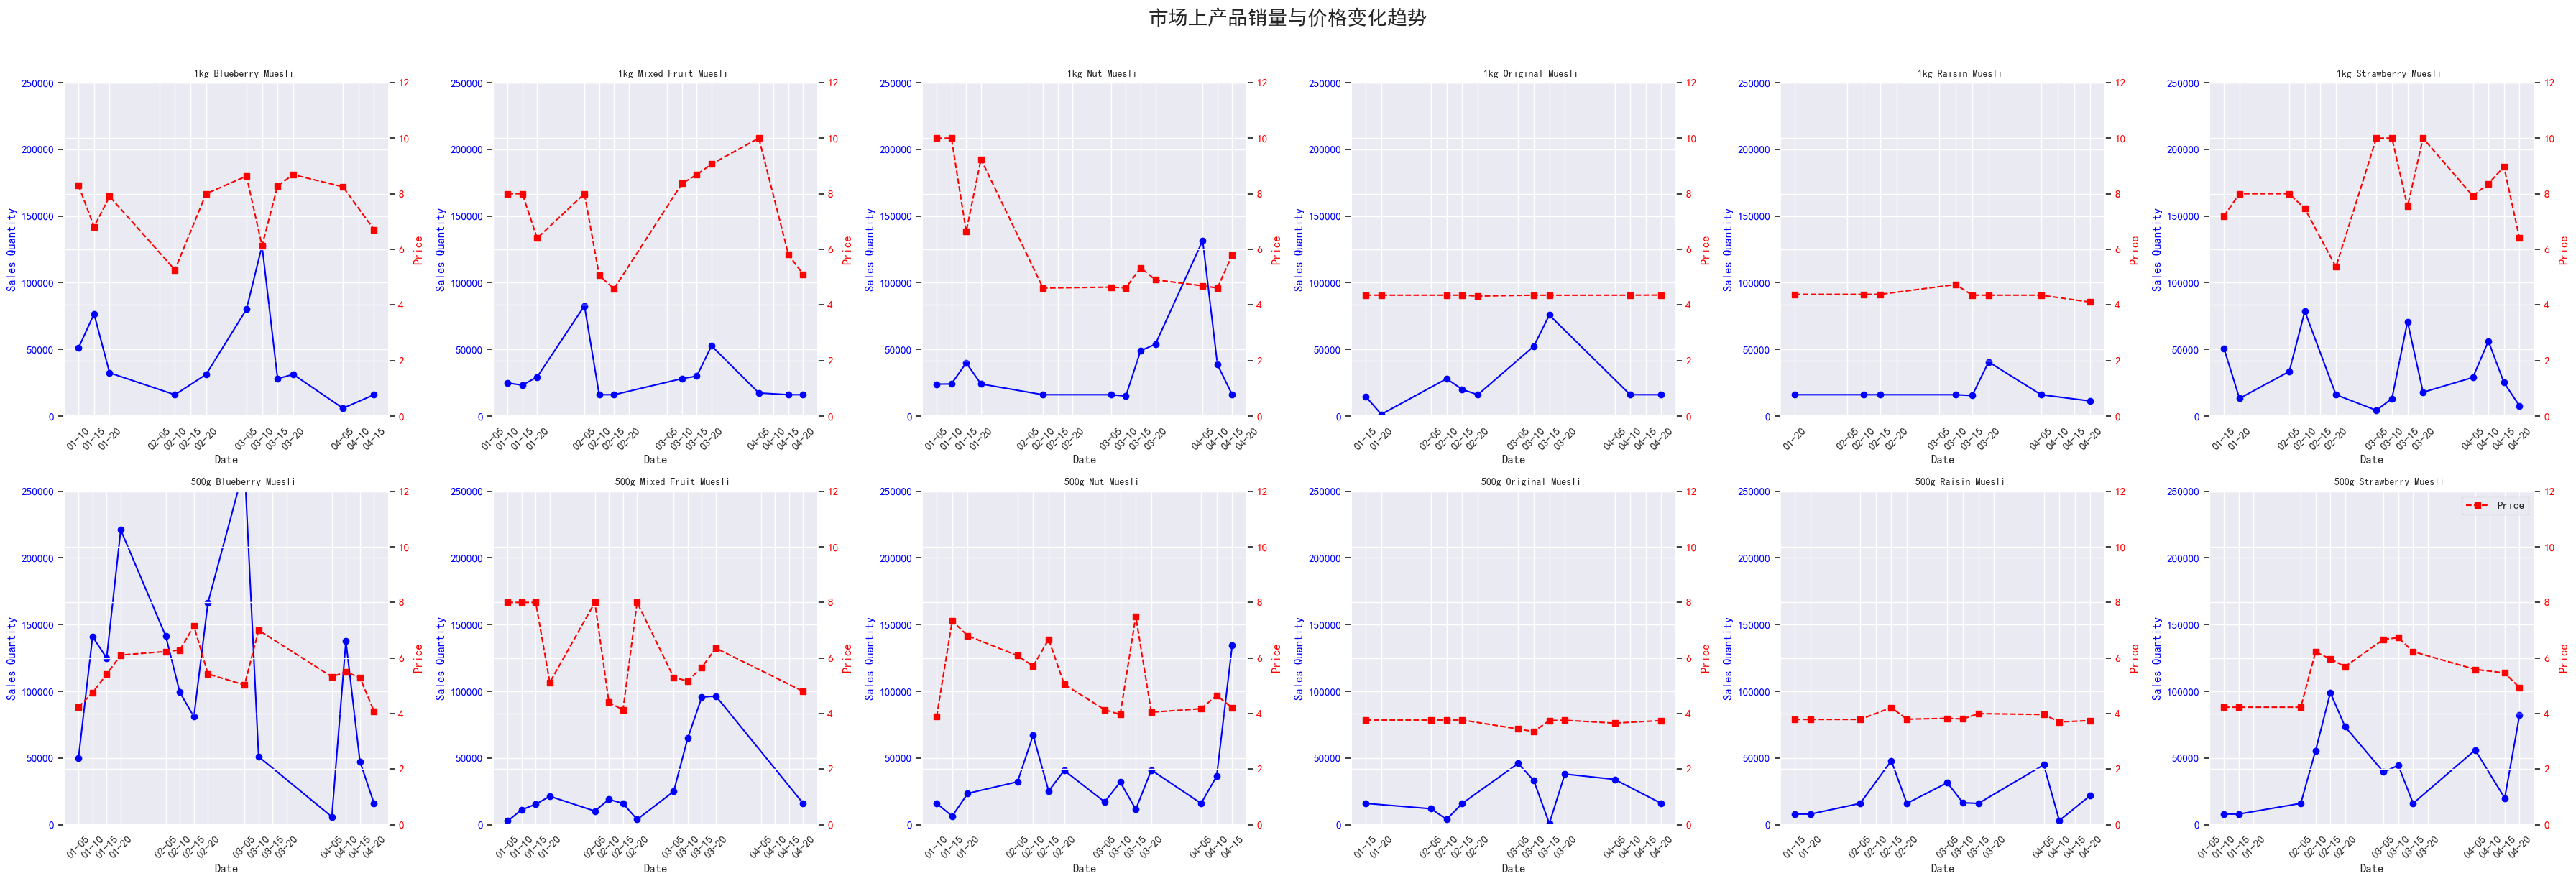

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# 读取Excel数据（包含Price列）
df = pd.read_excel('市场销售报告.xlsx', sheet_name='Sheet1')
rows, _ = df.shape

# 提取所需列（新增Price列）
df = df.loc[6:rows, ['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 4', 'Unnamed: 6']]
df.columns = ['Date', 'Material Description', 'Qty', 'Price']

# 数据处理
df['Date'] = df['Date'].str.strip()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d')

df['Qty'] = df['Qty'].str.replace(',', '').astype(float)
df['Price'] = df['Price'].astype(float)

# 按产品和日期聚合（总销量 + 平均价格）
grouped = df.groupby(['Material Description', 'Date']).agg({'Qty': 'sum', 'Price': 'mean'}).reset_index()

products = grouped['Material Description'].unique()
sns.set_theme()
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
fig, axes = plt.subplots(2, 6, figsize=(36, 12))
fig.suptitle('市场上产品销量与价格变化趋势', fontsize=20, y=1.02)
plt.subplots_adjust(hspace=0.5, wspace=0.3)

for idx, product in enumerate(products):
    ax = axes[idx // 6, idx % 6]
    data = grouped[grouped['Material Description'] == product]

    ax.plot(data['Date'], data['Qty'], marker='o', linestyle='-', color='blue', label='Sales Qty')
    ax.set_title(product, fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Sales Quantity', color='blue')
    ax.tick_params(axis='y', labelcolor='blue')
    ax.set_ylim(0, 250000)

    ax2 = ax.twinx()
    ax2.plot(data['Date'], data['Price'], marker='s', linestyle='--', color='red', label='Price')
    ax2.set_ylabel('Price', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim(0, 12)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[5, 10, 15, 20]))
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.legend()
plt.savefig('市场销售报告.png', bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

图片已成功保存至: 商品净利润趋势图.png


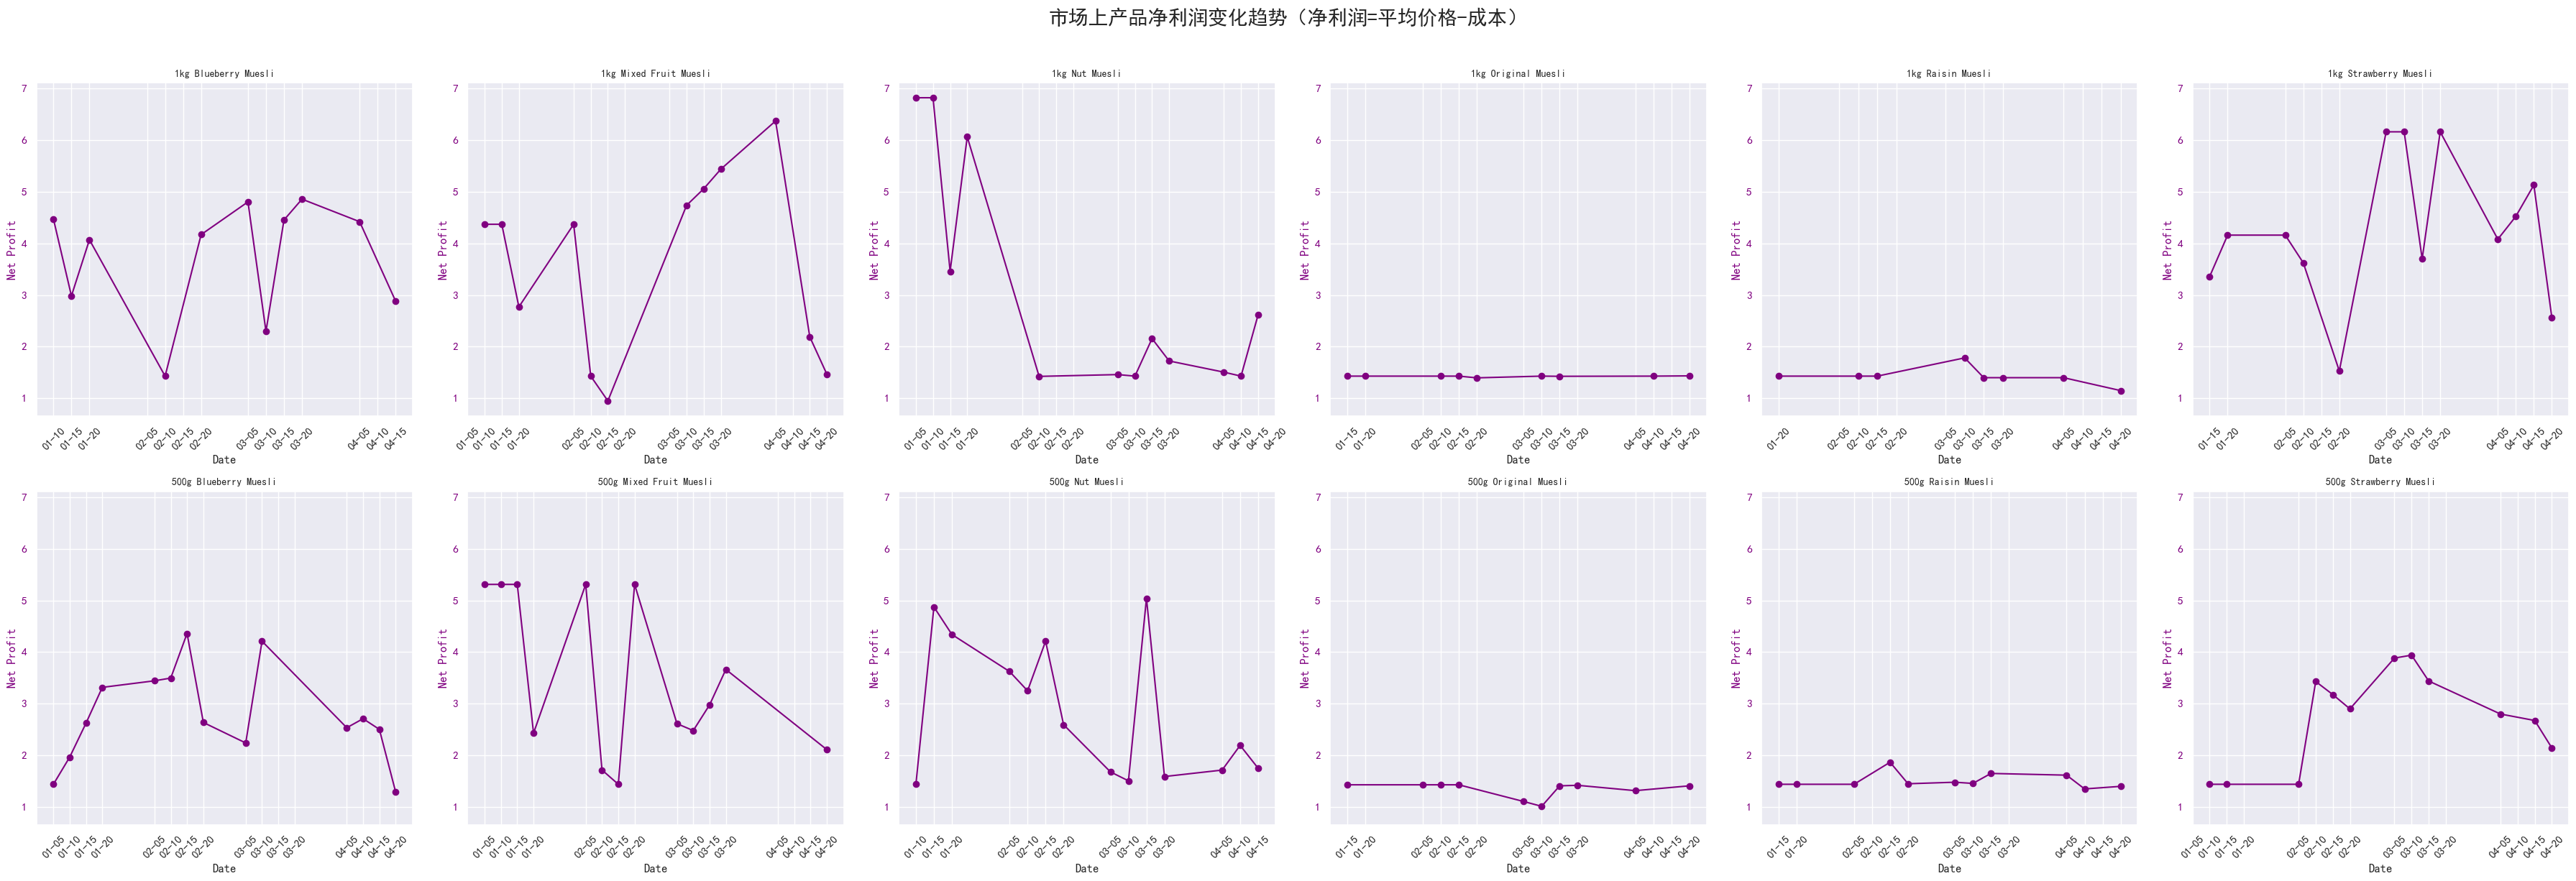

In [ ]:
# 任务：每种商品一个图（2x6），横坐标同原图，双纵坐标分别表示单件商品净利润和总净利润
# 净利润 = 平均价格 - 成本；总净利润 = 净利润 * 销量

# 成本表读取
cost_df = pd.read_excel('商品成本.xlsx')[['Description', 'Variable + Fixed']].copy()
cost_df.columns = ['Material Description', 'Cost']
cost_df['Material Description'] = cost_df['Material Description'].astype(str).str.strip()
cost_df['Cost'] = pd.to_numeric(cost_df['Cost'], errors='coerce')

# 与市场数据合并
profit_df = grouped.copy()
profit_df['Material Description'] = profit_df['Material Description'].astype(str).str.strip()
profit_df = profit_df.merge(cost_df, on='Material Description', how='left')

missing = profit_df.loc[profit_df['Cost'].isna(), 'Material Description'].drop_duplicates().tolist()
if missing:
    print('以下商品未匹配到成本，净利润将显示为NaN：', missing)

profit_df['Net Profit'] = profit_df['Price'] - profit_df['Cost']
profit_df['Total Profit'] = profit_df['Net Profit'] * profit_df['Qty']

products2 = profit_df['Material Description'].dropna().unique()
fig, axes = plt.subplots(2, 6, figsize=(36, 12))
fig.suptitle('市场上产品净利润与总净利润变化趋势', fontsize=20, y=1.02)
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# 计算全局统一的 Y 轴范围：1为单件净利润，2为总净利润
global_min1 = profit_df['Net Profit'].min()
global_max1 = profit_df['Net Profit'].max()
margin1 = (global_max1 - global_min1) * 0.05
if margin1 == 0: margin1 = 1

global_min2 = profit_df['Total Profit'].min()
global_max2 = profit_df['Total Profit'].max()
margin2 = (global_max2 - global_min2) * 0.05
if margin2 == 0: margin2 = 10

for idx, product in enumerate(products2[:12]):
    ax = axes[idx // 6, idx % 6]
    d = profit_df[profit_df['Material Description'] == product].sort_values('Date')

    # 左侧Y轴：单件商品净利润（紫）
    ax.plot(d['Date'], d['Net Profit'], marker='o', linestyle='-', color='purple', label='Unit Net Profit')
    ax.set_ylim(global_min1 - margin1, global_max1 + margin1)
    
    ax.set_title(product, fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Net Profit (Unit)', color='purple')
    ax.tick_params(axis='y', labelcolor='purple')

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(bymonthday=[5, 10, 15, 20]))
    plt.setp(ax.get_xticklabels(), rotation=45)

    # 右侧Y轴：总净利润（绿）
    ax2 = ax.twinx()
    ax2.plot(d['Date'], d['Total Profit'], marker='s', linestyle='--', color='green', label='Total Net Profit')
    ax2.set_ylabel('Total Net Profit', color='green')
    ax2.tick_params(axis='y', labelcolor='green')
    ax2.set_ylim(global_min2 - margin2, global_max2 + margin2)

# 不足12个商品时删掉空图
for j in range(len(products2), 12):
    fig.delaxes(axes[j // 6, j % 6])

plt.tight_layout()

save_path = '商品与总净利润趋势对比图.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
print(f"图片已成功保存至: {save_path}")

plt.show()


图片已成功保存至: 轮数净利润占比图.png


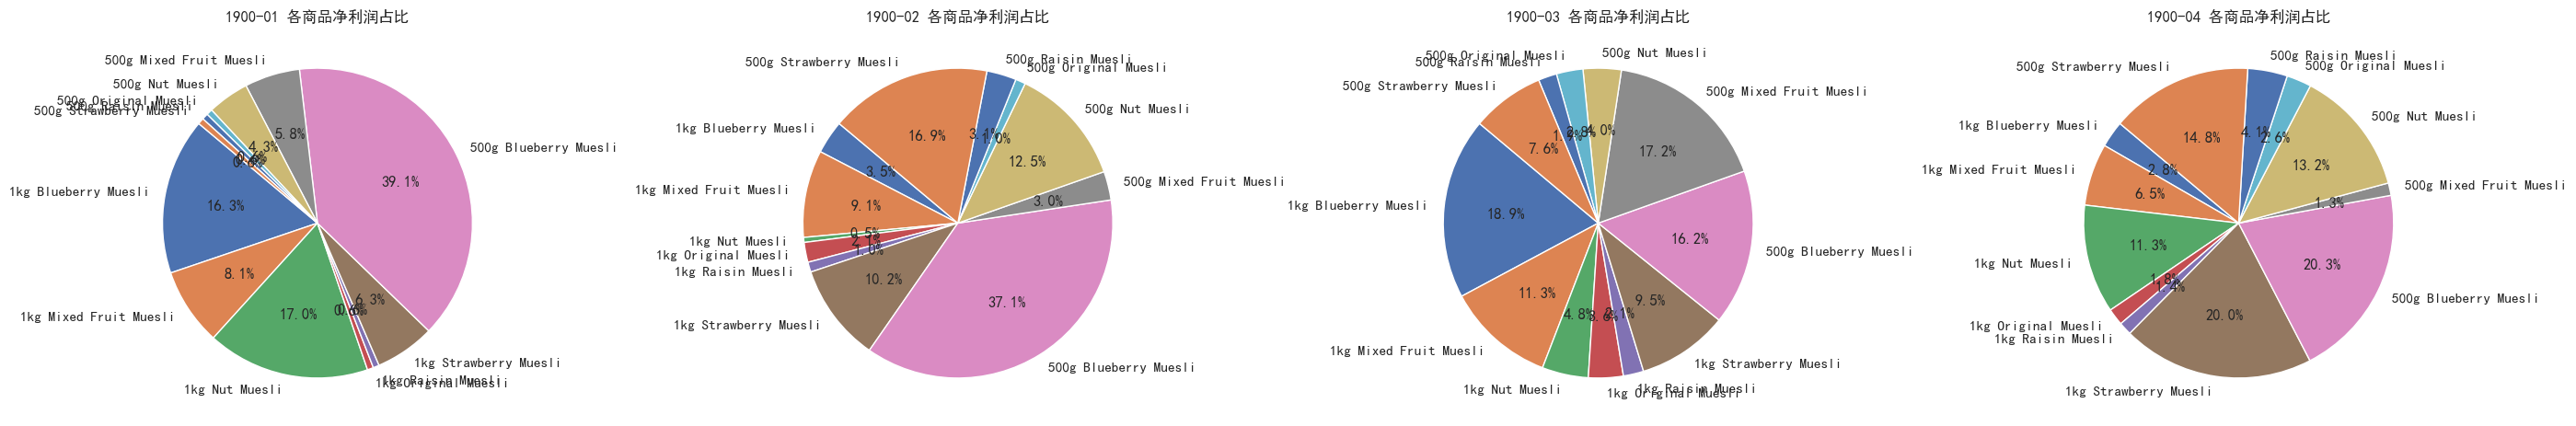

In [ ]:
# 任务二：根据上一个cell，按月份画净利润占比饼图（最多4个；若只有2个月就画2个）

pie_df = profit_df.dropna(subset=['Date', 'Material Description', 'Net Profit']).copy()
pie_df['Month'] = pie_df['Date'].dt.to_period('M').astype(str)

# 每月每商品总利润（总利润 = 净利润 * 销量）
pie_df['Total Profit'] = pie_df['Net Profit'] * pie_df['Qty']
month_profit = pie_df.groupby(['Month', 'Material Description'], as_index=False)['Total Profit'].sum()
months = sorted(month_profit['Month'].unique())[:4]
n = len(months)

if n == 0:
    print('没有可用于绘制饼图的月份数据')
else:
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
    if n == 1:
        axes = [axes]

    for i, m in enumerate(months):
        ax = axes[i]
        mdf = month_profit[month_profit['Month'] == m].copy()

        # 饼图不能有负值，负净利润不参与占比
        mdf['PieValue'] = mdf['Total Profit'].clip(lower=0)
        mdf = mdf[mdf['PieValue'] > 0]

        if mdf.empty:
            ax.text(0.5, 0.5, f'{m} 无正净利润数据', ha='center', va='center')
            ax.axis('off')
            continue

        ax.pie(mdf['PieValue'], labels=mdf['Material Description'], autopct='%1.1f%%', startangle=140)
        ax.set_title(f'{m} 各商品净利润占比')

    plt.tight_layout()

    # --- 核心新增部分：保存图片 ---
    # 你可以更改文件名，例如 'profit_analysis.png' 或 'profit_analysis.pdf'
    save_path = '轮数净利润占比图.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight') 
    print(f"图片已成功保存至: {save_path}")
    # ---------------------------
    
    plt.show()